In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib import rcParams
%matplotlib inline
from sklearn.datasets import make_blobs
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


In [2]:
df=pd.read_csv("Teen_Mental_Health_Dataset.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [3]:
df.index

RangeIndex(start=0, stop=1200, step=1)

In [5]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [7]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1195    False
1196    False
1197    False
1198    False
1199    False
Length: 1200, dtype: bool

In [11]:
df['platform_usage'].value_counts()

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

In [14]:
pd.set_option("display.max_rows",None)

In [15]:
df['academic_performance'].value_counts()

academic_performance
3.90    13
2.36    13
2.84    12
2.91    12
2.29    12
3.01    11
3.33    11
3.71    11
3.82    11
3.91    11
3.98    10
2.54    10
3.19    10
2.56    10
3.81    10
2.22     9
2.51     9
2.17     9
3.42     9
3.40     9
3.27     9
2.99     9
3.72     9
2.50     9
3.22     9
2.77     9
2.28     9
2.85     9
2.61     8
3.41     8
3.77     8
3.48     8
2.04     8
3.65     8
2.80     8
3.69     8
2.55     8
3.83     8
3.05     8
2.53     8
3.08     8
3.20     8
3.67     8
2.62     8
3.10     8
2.12     8
3.76     8
2.35     8
3.34     8
3.45     7
3.68     7
3.25     7
2.98     7
3.47     7
3.97     7
2.52     7
2.47     7
2.69     7
2.75     7
2.03     7
2.63     7
3.30     7
3.15     7
3.13     7
3.53     7
2.06     7
2.67     7
3.16     7
2.24     7
2.11     7
3.50     7
3.29     7
2.76     7
3.32     7
2.48     7
2.20     7
2.13     7
2.49     7
3.04     7
2.44     7
2.74     7
2.18     7
2.68     7
2.95     6
2.07     6
2.33     6
3.09     6
3.54     6
2.88     6


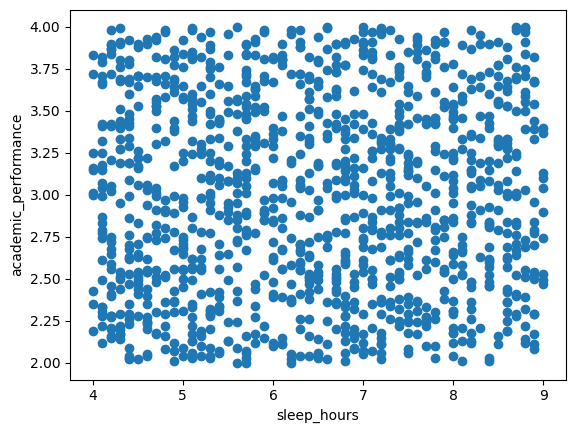

In [16]:
plt.scatter(data = df, x = 'sleep_hours', y = 'academic_performance');
plt.xlabel('sleep_hours');
plt.ylabel('academic_performance');


In [26]:
df_encoded = pd.get_dummies(df, columns=['gender', 'platform_usage', 'social_interaction_level'], drop_first=True)
df_encoded

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,True,True,False,True,False
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,False,False,True,False,False
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,False,True,False,False,False
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,True,False,True,False,True
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,False,False,False,False,True
5,19,7.4,4.4,2.4,2.63,0.6,3,5,7,0,False,False,False,False,False
6,18,2.5,6.4,2.4,2.63,0.7,2,2,5,0,False,True,False,True,False
7,16,4.0,4.2,0.5,2.40,1.3,6,10,5,0,True,False,False,True,False
8,19,3.3,5.0,2.1,2.04,0.9,1,10,9,0,False,False,True,False,False
9,15,1.9,4.9,1.5,3.77,1.1,1,1,4,0,True,False,True,False,False


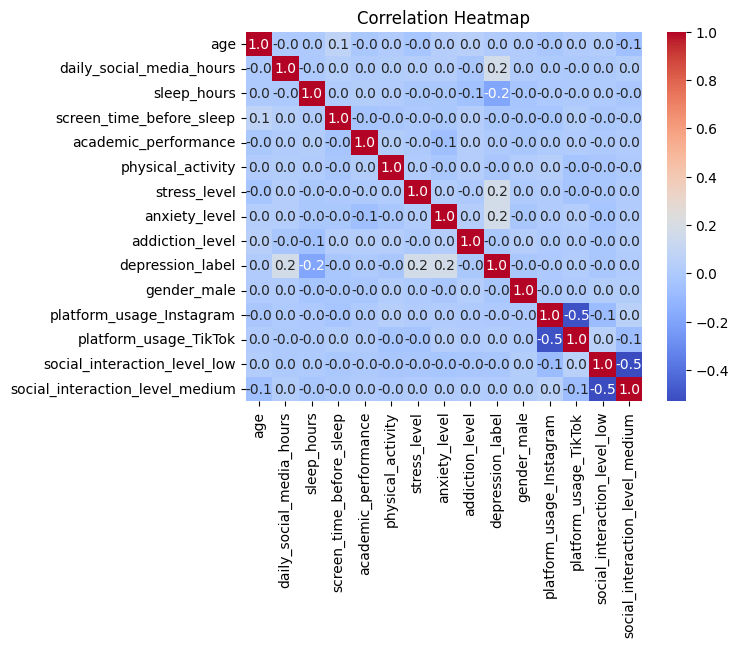

In [29]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=True, fmt=".1f")
plt.title("Correlation Heatmap")
plt.show()



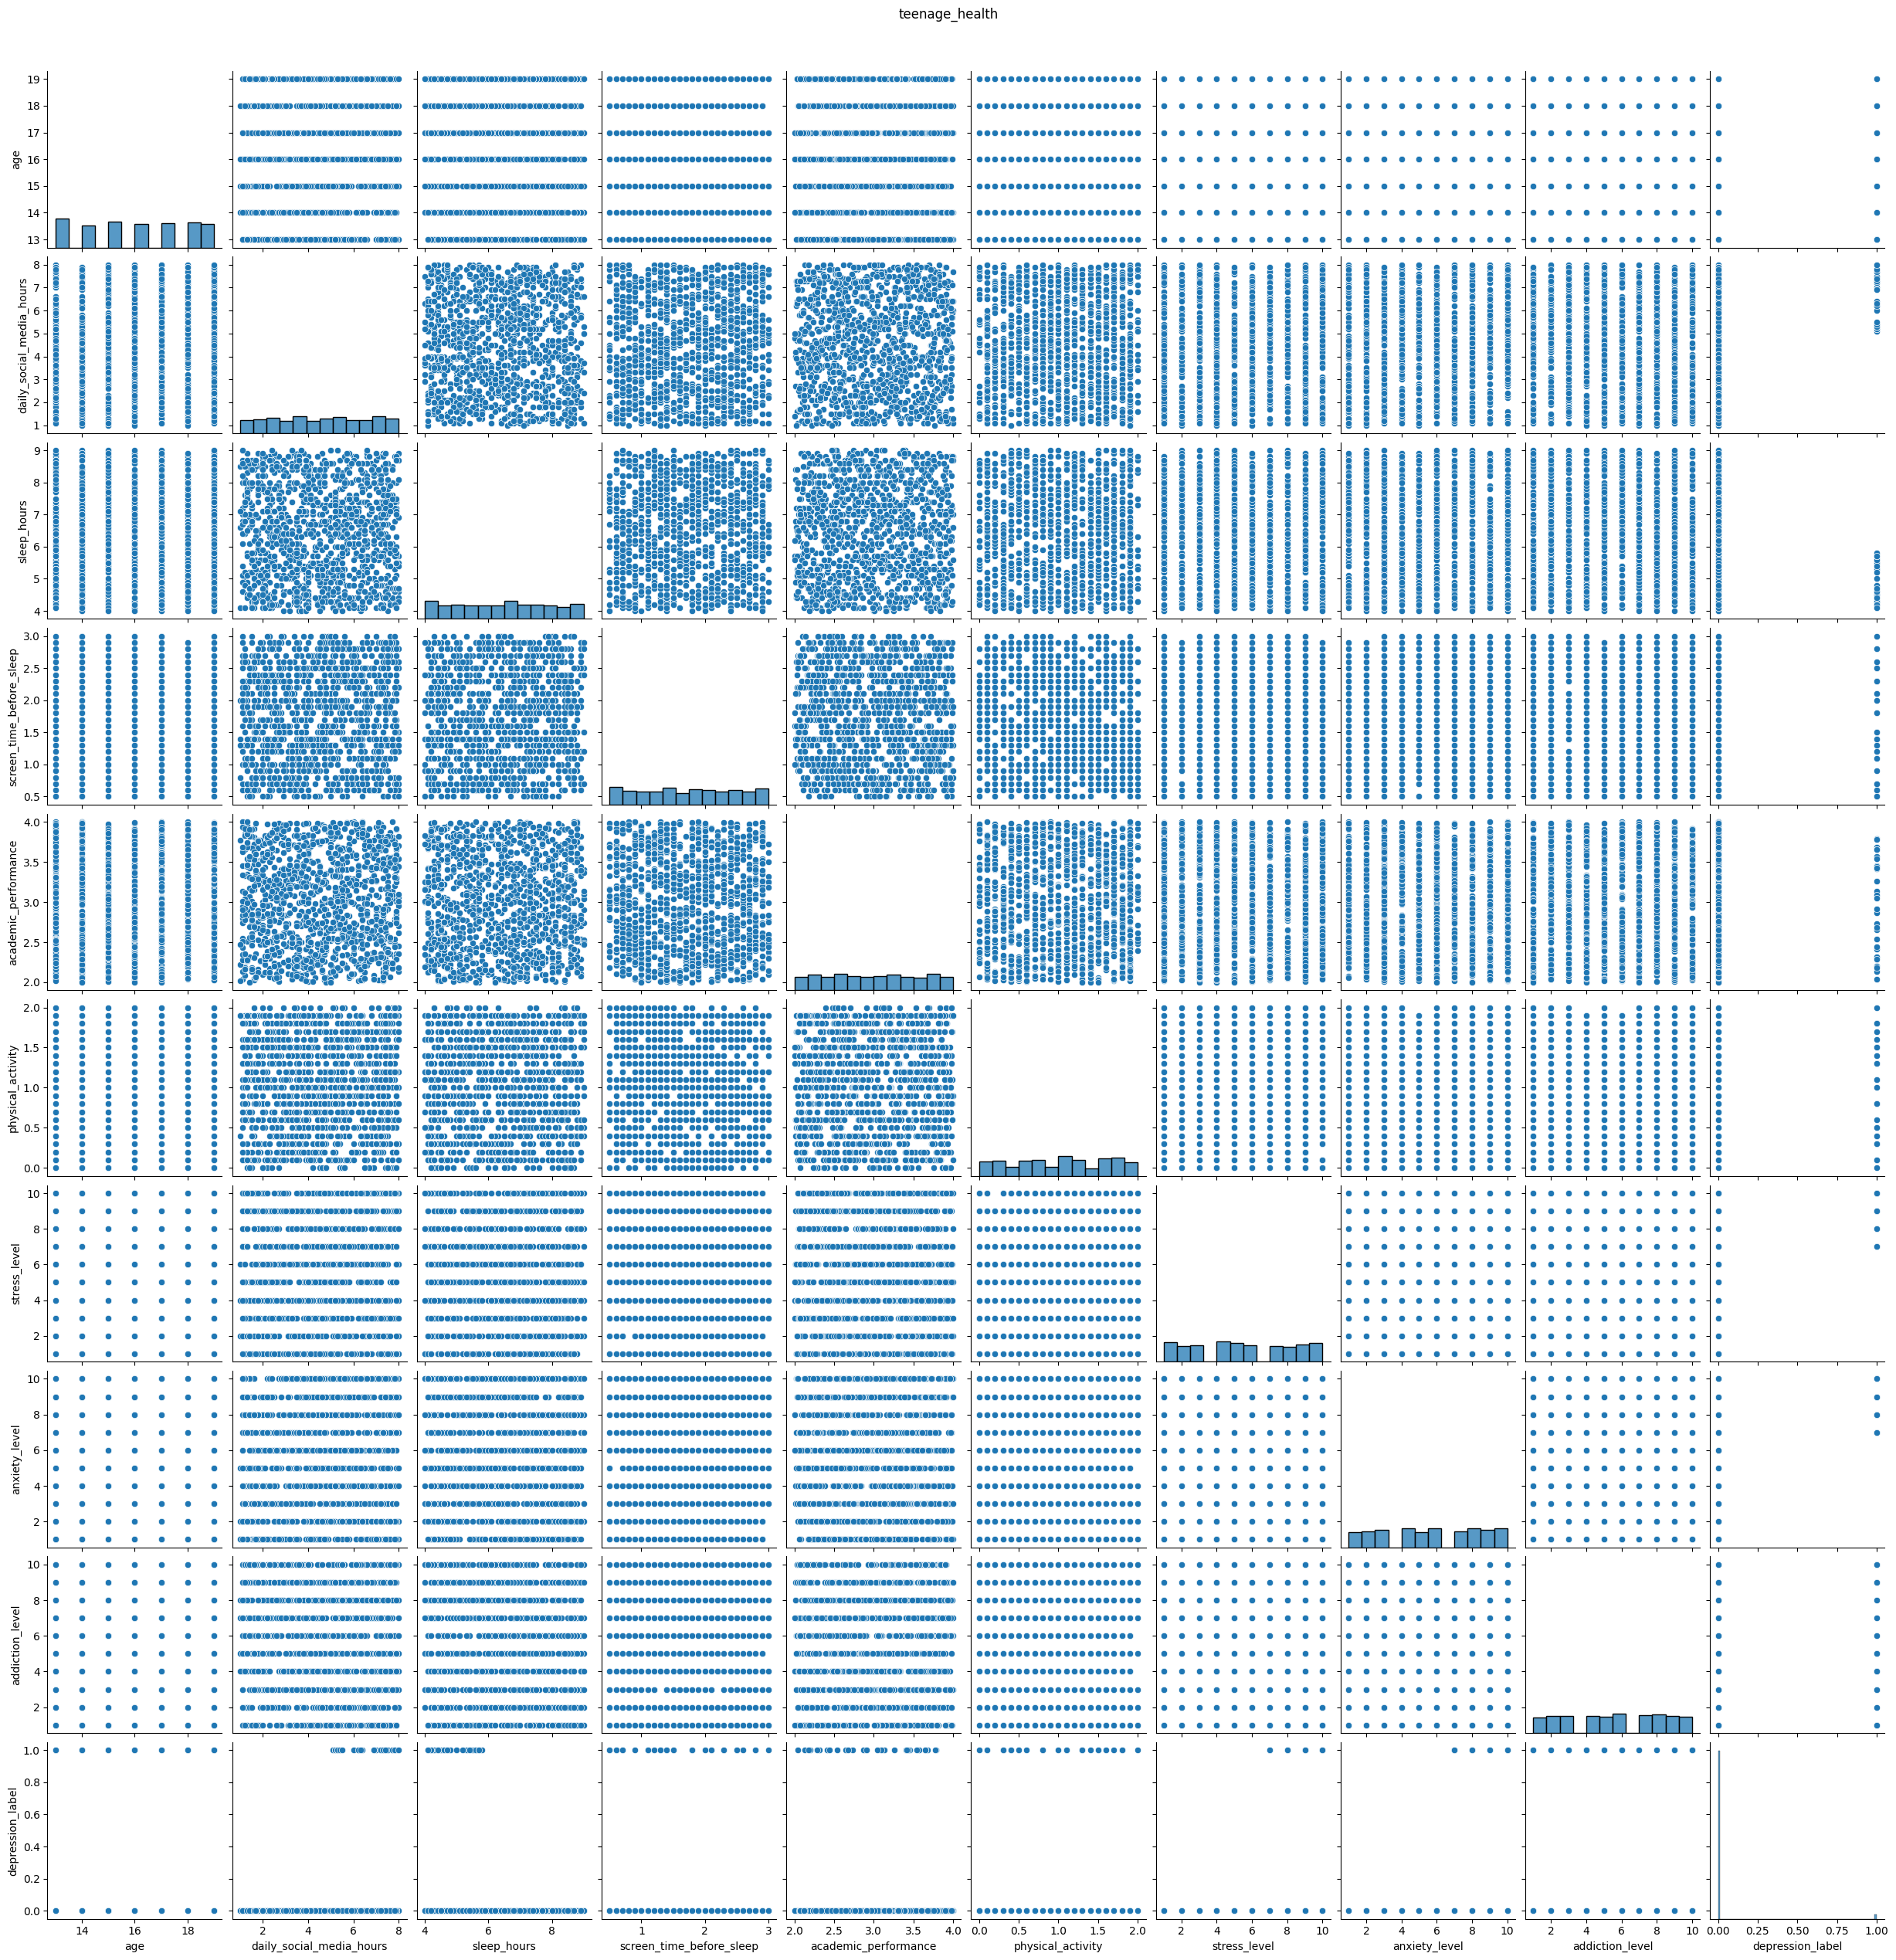

In [25]:
sns.pairplot(df)
plt.suptitle("teenage_health", y=1.02)
plt.show()